 # EMI Conduction velocity I

An advantage of the EMI framework is that it allows ion channels to be non-uniformly distributed along the cell membrane. Such features are difficult to include in classical homogenized models. In this and the following notebook, we extend our toy single-cell example to a chain of 3D cells. We will examine the effect of clustered versus uniformly distributed ion channels, as demonstrated by [Tveito et al. (2017)](https://doi.org/10.3389/fphy.2017.00048){cite}`emiconduction-tveito2017cell`. While that study used a 30x5 grid of cells, we will simplify our domain to a single strand of six cells. 

This experiment is split into two parts:
1. **Uniform Distribution (this notebook):** We establish our baseline by spreading sodium channels ($g_{Na}$) evenly across the entire cell membrane.
2. **Clustered Distribution (next notebook):** We will concentrate the sodium channels at the ends of the cells.

## EMI Framework

The Extracellular-Membrane-Intracellular (EMI) framework explicitly models cells by representing the extracellular space ($\Omega_e$), intracellular spaces ($\Omega_i^k$ for cell $k$), and the interfaces between them as separate geometrical domains.

### The EMI system (Extended with gap junctions)

Compared to a single-cell model, simulating a chain of cells introduces a new type of interface: the gap junctions ($\Gamma_{j,k}$) connecting adjacent cells.

\
![emi_domain](figures/emi_domain_twocell.png)

*An EMI domain with two cells sharing a gap junction. Figure from [Tveito et al. (2017)](https://doi.org/10.3389/fphy.2017.00048){cite}`emiconduction-tveito2017cell`.*

\
The complete system is:

\begin{align*}
    \nabla \cdot \sigma_e\nabla u_e &= 0&& \text{in } \Omega_e \tag{1}\\
    \nabla \cdot \sigma_i\nabla u_i^k &= 0&& \text{in } \Omega_i^k \tag{2}\\
    u_e &= 0&& \text{at } \partial \Omega \tag{3} \\
    \mathbf{n}_e \cdot \sigma_e\nabla u_e &= - \mathbf{n}_i^k \cdot \sigma_i\nabla u_i^k \equiv I_m^k &&\text{at } \Gamma_k \tag{4}\\
    u_i^k - u_e &= v^k&& \text{at } \Gamma_k \tag{5}\\
    \frac{\partial v^k}{\partial t} &= \frac{1}{C_m}(I_m^k-I_{ion}^k)&& \text{at } \Gamma_k \tag{6} \\
    \mathbf{n}_i^j \cdot \sigma_i\nabla u_i^j &= - \mathbf{n}_i^k \cdot \sigma_i\nabla u_i^k \equiv I_{j,k}&& \text{at } \Gamma_{j,k} \tag{7}\\
    u_i^j - u_i^k &= w^{j,k} && \text{at } \Gamma_{j,k} \tag{8}\\
    \frac{\partial w^{j,k}}{\partial t} &= \frac{1}{C_{gap}} (I_{j,k} - I_{gap}) && \text{at } \Gamma_{j,k} \tag{9}
\end{align*}

1. **The Bulk Tissue** (Eqs. 1-3)
Electrical conduction follows the steady-state Laplace equation in both the intracellular spaces ($\Omega_i^k$) and the shared extracellular space ($\Omega_e$). The system is closed with a Dirichlet boundary condition on the outer boundary of the extracellular domain ($\partial \Omega_e$).

2. **The Cell Membrane** (Eqs. 4-6)
At the membrane ($\Gamma_k$), the normal flux exiting the intracellular space must equal the flux entering the extracellular space. This continuous flux is the total transmembrane current ($I_m^k$). The dynamic evolution of the transmembrane potential ($v^k$) is governed by this current charging the membrane capacitance ($C_m$), minus the nonlinear biophysical ionic currents ($I_{ion}^k$).

3. **The Gap Junctions** (Eqs. 7-9)
Where adjacent cells $j$ and $k$ touch ($\Gamma_{j,k}$), the intracellular flux must remain continuous. This transcellular gap current ($I_{j,k}$) is driven by the voltage jump between the two connected cells ($w^{j,k}$). The current must overcome both the gap junction's physical capacitance ($C_{gap}$) and its resistance, characterized by the passive gap current $I_{gap} = w^{j,k} / R_{gap}$.

### Membrane model
The membrane model defines the biological ionic currents ($I_{ion}^k$) across the membrane in Equation 6. Depending on the required detail, this can be represented by simplified phenomenological equations (such as the FitzHugh-Nagumo model) or highly detailed biophysical formulations (such as the Hodgkin-Huxley or Grandi models) that track the specific voltage-gated kinetics of individual ion channels like sodium, potassium, and calcium.
In this example, as in Tveito et al. (2017), we use the [Grandi membrane model](https://doi.org/10.1016/j.yjmcc.2009.09.019){cite}`emiconduction-grandi2010novel`. 

## FEniCS implementation

We begin by importing the necessary libraries. The Grandi ODE model is contained in `grandi.py`, and `emimesh.py` provides the Gmsh geometry definitions to build our 3D cell strand.


In [ ]:
import numpy as np

from dolfinx import fem, mesh, io, plot, default_scalar_type
from ufl import (
    inner,
    grad,
    TestFunctions,
    TrialFunctions,
    SpatialCoordinate,
    conditional,
    MixedFunctionSpace,
    extract_blocks,
    Measure,
)
import scifem
import pyvista

pyvista.set_jupyter_backend("static")

import grandi
from emimesh import generate_emi_mesh, scale, step_x, step_y, step_z

### Mesh generation and submesh extraction

To keep computational times manageable, we generate a short strand of 6 cells. Using `scifem`, we extract dedicated submeshes for the shared extracellular space and each individual intracellular domain.

The extracellular space has cell tag 1, and intracellular domains are numbered $(2, 3, \ldots,  N_{cells} + 1)$.
We also generate specific facet markers: cell membranes $\Gamma_k$ are given unique tags $(10, 11, 12, \ldots)$, and gap junctions $\Gamma_{j,k}$ are marked separately $(100, 101, 102, \ldots)$.

In [2]:
N_cells = 6

omega, ct, ft = generate_emi_mesh(N_cells=(N_cells, 1, 1))


# Extract extracellular submesh
omega_e, e_to_p, _, _, _ = scifem.extract_submesh(omega, ct, 1)

# Extract intracellular submesh for each cell
omega_i, i_to_p = {}, {}
for k in range(N_cells):
    omega_i[k], i_to_p[k], _, _, _ = scifem.extract_submesh(omega, ct, 2 + k)

# Collect entity maps
entity_maps = [e_to_p] + [i_to_p[k] for k in range(N_cells)]

dx = Measure("dx", domain=omega, subdomain_data=ct)
dxE = dx(1)
dxI = {k: dx(2 + k) for k in range(N_cells)}

subdomain_data_list = []
for k in range(N_cells):
    subdomain_data_list.append(
        (10 + k, scifem.compute_interface_data(ct, ft.find(10 + k)).flatten())
    )
    subdomain_data_list.append(
        (20 + k, scifem.compute_interface_data(ct, ft.find(20 + k)).flatten())
    )
    if k < N_cells - 1:
        subdomain_data_list.append(
            (100 + k, scifem.compute_interface_data(ct, ft.find(100 + k)).flatten())
        )


gamma_mem, gamma_gap = {}, {}
for k in range(N_cells):
    gamma_mem[k] = scifem.find_interface(ct, 1, 2 + k)
    if k < N_cells - 1:
        gamma_gap[k] = scifem.find_interface(ct, 2 + k, 3 + k)

omega.topology.create_connectivity(omega.topology.dim - 1, omega.topology.dim)
num_facets = (
    omega.topology.index_map(omega.topology.dim - 1).size_local
    + omega.topology.index_map(omega.topology.dim - 1).num_ghosts
)
marker = np.full(num_facets, -1, dtype=np.int32)

for k in range(N_cells):
    marker[gamma_mem[k]] = 10 + k
    if k < N_cells - 1:
        marker[gamma_gap[k]] = 100 + k

marker_filter = np.flatnonzero(marker != -1).astype(np.int32)
ft_unique = mesh.meshtags(
    omega, omega.topology.dim - 1, marker_filter, marker[marker_filter]
)
ft_unique.name = "facet_tags"

Run the cell below to visualize the 3D mesh and verify that our cell and facet markers are correctly set.

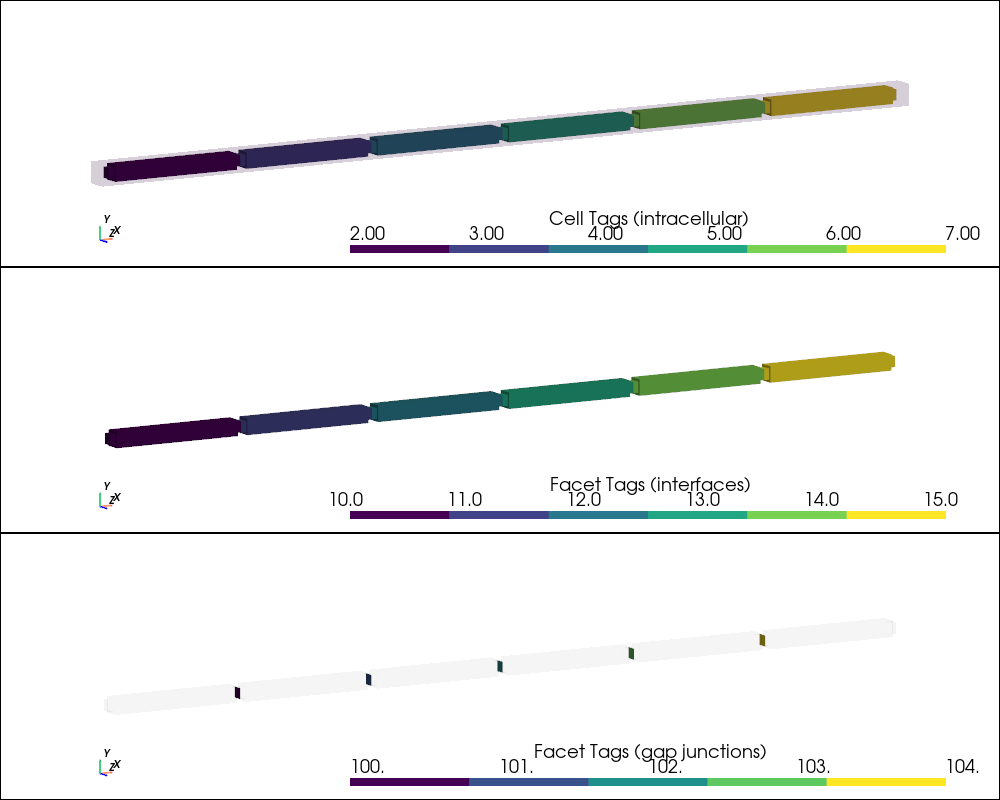

In [3]:
pv_grid_cell = pyvista.UnstructuredGrid(*plot.vtk_mesh(omega))
pv_grid_cell.cell_data["Cell Tags"] = ct.values
extracellular_grid = pv_grid_cell.threshold([1, 1])
intracellular_grid = pv_grid_cell.threshold(2)

pv_grid_facet = pyvista.UnstructuredGrid(
    *plot.vtk_mesh(omega, omega.topology.dim - 1, ft_unique.indices)
)
pv_grid_facet.cell_data["Facet Tags"] = ft_unique.values
interface_grid = pv_grid_facet.threshold([10, 19])
gap_grid = pv_grid_facet.threshold([100, 1000])

plotter = pyvista.Plotter(shape=(3, 1), window_size=[1000, 800])

plotter.subplot(0, 0)
plotter.add_mesh(extracellular_grid, opacity=0.1, show_scalar_bar=False)
plotter.add_mesh(
    intracellular_grid,
    categories=True,
    scalar_bar_args={"title": "Cell Tags (intracellular)", "n_labels": N_cells},
    n_colors=N_cells,
)

plotter.subplot(1, 0)
plotter.add_mesh(
    interface_grid,
    categories=True,
    scalar_bar_args={"title": "Facet Tags (interfaces)", "n_labels": N_cells},
    n_colors=N_cells,
)

plotter.subplot(2, 0)
plotter.add_mesh(intracellular_grid, opacity=0.03, color="gray")
plotter.add_mesh(
    gap_grid,
    categories=True,
    scalar_bar_args={"title": "Facet Tags (gap junctions)", "n_labels": N_cells - 1},
    n_colors=N_cells - 1,
)
plotter.camera.tight(padding=0.1, adjust_render_window=False)
plotter.camera.azimuth = -30
plotter.camera.elevation = 10
plotter.link_views(2)

plotter.show_axes_all()
plotter.show()

### Model parameters
Next we define the model parameters. The values here follow those used in [Tveito et al. (2017)](https://doi.org/10.3389/fphy.2017.00048){cite}`emiconduction-tveito2017cell`.

In [4]:
# Simulation parameters
dt_val = 0.005
sim_time = 2.0

# Physical parameters
sigma_e = fem.Constant(omega, 20.0)  # mS/cm
sigma_i = fem.Constant(omega, 5.0)  # mS/cm
dt = fem.Constant(omega, dt_val)  # ms
Cm = fem.Constant(omega, 1.0)  # µF/cm^2
C_gap = fem.Constant(omega, 1.0)  # µF/cm^2
R_gap = fem.Constant(omega, 0.0015)  # kΩcm2
g_Na = fem.Constant(omega, 23.0)  # mS/µF
v_rest = -85  # mV

### Function spaces and state variables

We assign a piecewise linear (CG1) function space to each individual submesh. To solve the coupled system simultaneously, we combine the spaces into a single `MixedFunctionSpace`. We also initialize the FEniCSx variables that will hold our current and previous spatial solutions, alongside the internal state variables for the Grandi ODE model.

In [5]:
Ve = fem.functionspace(omega_e, ("Lagrange", 1))
Vi = {k: fem.functionspace(omega_i[k], ("Lagrange", 1)) for k in range(N_cells)}

# Build the mixed space
space_list = [Ve] + [Vi[k] for k in range(N_cells)]
W = MixedFunctionSpace(*space_list)

trial_functions = TrialFunctions(W)
test_functions = TestFunctions(W)

ue, ve = trial_functions[0], test_functions[0]
ui = {k: trial_functions[k + 1] for k in range(N_cells)}
vi = {k: test_functions[k + 1] for k in range(N_cells)}

# Initialize PDE states
ue_sol = fem.Function(Ve)
ui_sol = {k: fem.Function(Vi[k]) for k in range(N_cells)}
ue_n = fem.Function(Ve)
ui_n = {k: fem.Function(Vi[k]) for k in range(N_cells)}
t_act = {k: fem.Function(Vi[k]) for k in range(N_cells)}
for k in range(N_cells):
    ui_sol[k].x.array[:] = v_rest
    ui_n[k].x.array[:] = v_rest
    t_act[k].x.array[:] = -1.0

# Initialize Grandi states
grandi_states = {k: grandi.init_states(len(ui_sol[k].x.array)) for k in range(N_cells)}
d_states_dict = {k: np.zeros_like(grandi_states[k]) for k in range(N_cells)}
I_ion_func = {k: fem.Function(Vi[k]) for k in range(N_cells)}


### Integration measures

Next, we create the integration measures. We use `dx` for volume integration and `dS` for the internal interfaces (membranes and gap junctions).
The function `scifem.compute_interface_data` is used to define consistent positive (+) and negative (-) sides for each interface, which is required to ensure correct flux calculations.

In [6]:
dx = Measure("dx", domain=omega, subdomain_data=ct)
dxE = dx(1)
dxI = {k: dx(2 + k) for k in range(N_cells)}

subdomain_data_list = []
for k in range(N_cells):
    subdomain_data_list.append(
        (10 + k, scifem.compute_interface_data(ct, ft_unique.find(10 + k)).flatten())
    )
    if k < N_cells - 1:
        subdomain_data_list.append(
            (
                100 + k,
                scifem.compute_interface_data(ct, ft_unique.find(100 + k)).flatten(),
            )
        )

dS = Measure("dS", domain=omega, subdomain_data=subdomain_data_list)

### Stimulus current
To trigger the action potential, we apply an artificial stimulus current strictly to the left tip of the first cell. This will initiate our traveling wave.

In [7]:
x = SpatialCoordinate(omega)
I_stim_amp = fem.Constant(omega, 0.0)  # to be updated in loop
stim_mask = conditional(x[0] <= 24.0 * scale, 1.0, 0.0)

### Variational formulation

We can now assemble the standard weak form of the EMI equations.

In [8]:
# Bulk terms
a = sigma_e * inner(grad(ue), grad(ve)) * dxE
for k in range(N_cells):
    a += sigma_i * inner(grad(ui[k]), grad(vi[k])) * dxI[k]
L = fem.Constant(omega, 0.0) * ve * dxE


# Membrane terms
for k in range(N_cells):
    v_m = ui[k]("-") - ue("+")
    w_v = vi[k]("-") - ve("+")
    v_m_n = ui_n[k]("-") - ue_n("+")

    stimulus = (I_stim_amp * stim_mask)("-") if k == 0 else fem.Constant(omega, 0.0)

    a += (Cm / dt) * v_m * w_v * dS(10 + k)
    L += ((Cm / dt) * v_m_n - I_ion_func[k]("-") + stimulus) * w_v * dS(10 + k)


# Gap junction terms
for k in range(N_cells - 1):
    w_jump = ui[k]("+") - ui[k + 1]("-")
    w_test = vi[k]("+") - vi[k + 1]("-")
    w_prev = ui_n[k]("+") - ui_n[k + 1]("-")

    a += (C_gap / dt + 1.0 / R_gap) * w_jump * w_test * dS(100 + k)
    L += (C_gap / dt) * w_prev * w_test * dS(100 + k)

### Boundary conditions

We close the system by grounding the extracellular potential at the outer boundary ($\partial\Omega$) to zero.

In [9]:
coords_e = omega_e.geometry.x
xe_min, xe_max = np.min(coords_e[:, 0]), np.max(coords_e[:, 0])
ye_min, ye_max = np.min(coords_e[:, 1]), np.max(coords_e[:, 1])
ze_min, ze_max = np.min(coords_e[:, 2]), np.max(coords_e[:, 2])


def outer_boundary_locator(x):
    x_bounds = np.isclose(x[0], xe_min) | np.isclose(x[0], xe_max)
    y_bounds = np.isclose(x[1], ye_min) | np.isclose(x[1], ye_max)
    z_bounds = np.isclose(x[2], ze_min) | np.isclose(x[2], ze_max)
    return x_bounds | y_bounds | z_bounds


outer_facets = mesh.locate_entities_boundary(
    omega_e, omega_e.topology.dim - 1, outer_boundary_locator
)
bc_ground = fem.dirichletbc(
    default_scalar_type(0.0),
    fem.locate_dofs_topological(Ve, omega_e.topology.dim - 1, outer_facets),
    Ve,
)

### Linear problem and solve
Here, we configure the FEniCSx `LinearProblem` to assemble and solve the coupled block system for both the extra- and intracellular potentials.

In [10]:
problem = fem.petsc.LinearProblem(
    extract_blocks(a),
    extract_blocks(L),
    u=[ue_sol] + [ui_sol[k] for k in range(N_cells)],
    bcs=[bc_ground],
    entity_maps=entity_maps,
    petsc_options={
        "ksp_type": "cg",
        "pc_type": "hypre",
        "ksp_rtol": 1e-6,
    },
    petsc_options_prefix="EMI_",
)

Before running the time loop, we define a Discontinuous Galerkin (DG) function to collect our outputs for writing to file, and we set up point-tracking in the middle of Cell 3 and Cell 5 to later calculate the macroscopic conduction velocity.

In [ ]:
# Combined solution for output
V_dg = fem.functionspace(omega, ("DG", 0))
u_out = fem.Function(V_dg, name="u")

vtx_file = io.VTXWriter(
    omega.comm, "output/EMI_chain_potential_uniform.bp", [u_out], engine="BP4"
)

local_cells_e = np.arange(
    omega_e.topology.index_map(omega_e.topology.dim).size_local, dtype=np.int32
)
local_cells_i = {
    k: np.arange(
        omega_i[k].topology.index_map(omega_i[k].topology.dim).size_local,
        dtype=np.int32,
    )
    for k in range(N_cells)
}

### Tracking wave propagation

To calculate the macroscopic conduction velocity (how fast the wave travels across the tissue), we need to record the exact time the action potential passes specific locations. 

In the snippet below, we set up tracking for the geometric centers of two adjacent cells further down the strand (Cell 3 and Cell 4). The variables `t1_val` and `t2_val` will store the activation times, initialized to `-1.0` to indicate the wave has not yet arrived.

In [12]:
cv_cell_1, cv_cell_2 = 3, 4
eval_pt_1 = np.array([(cv_cell_1 + 0.5) * step_x, (step_y / 2.0), (step_z / 2.0)])
eval_pt_2 = np.array([(cv_cell_2 + 0.5) * step_x, (step_y / 2.0), (step_z / 2.0)])
t1_val, t2_val, t = -1.0, -1.0, 0.0

Now, we are ready to run the main simulation loop:

In [ ]:
print("Starting simulation...")

for i in range(int(sim_time / dt_val)):
    t += dt_val
    I_stim_amp.value = 800.0 if (t >= 0.0 and t <= 1.0) else 0.0

    # 1. Step the FEniCSx Spatial PDE
    problem.solve()
    ue_n.x.array[:] = ue_sol.x.array[:]

    for k in range(N_cells):
        V_m = ui_sol[k].x.array

        # 2. Step the Grandi model
        I_tot = grandi.step_grandi(
            grandi_states[k], V_m, g_Na.value, dt_val, d_states_dict[k]
        )
        I_ion_func[k].x.array[:] = I_tot

        # 3. Tracking
        unactivated_mask = t_act[k].x.array < -0.5
        firing_mask = ui_sol[k].x.array >= 0.0
        t_act[k].x.array[unactivated_mask & firing_mask] = t
        ui_n[k].x.array[:] = ui_sol[k].x.array[:]

    v1 = scifem.evaluate_function(ui_sol[cv_cell_1], [eval_pt_1])[0, 0]
    v2 = scifem.evaluate_function(ui_sol[cv_cell_2], [eval_pt_2])[0, 0]
    if t1_val < 0.0 and v1 >= 0.0:
        t1_val = t
    if t2_val < 0.0 and v2 >= 0.0:
        t2_val = t
    if i % 25 == 0:
        print(
            f"Time: {t:.3f} ms | C{cv_cell_1}: {v1:.1f} mV | C{cv_cell_2}: {v2:.1f} mV"
        )
        # Update u_out and write to file
        for k in range(N_cells):
            u_out.interpolate(
                ui_sol[k],
                cells0=local_cells_i[k],
                cells1=i_to_p[k].sub_topology_to_topology(
                    local_cells_i[k], inverse=False
                ),
            )
        vtx_file.write(t)

vtx_file.close()
print("Simulation complete.")

Starting simulation...
Time: 0.005 ms | C3: -85.0 mV | C4: -85.0 mV
Time: 0.130 ms | C3: -84.8 mV | C4: -84.9 mV
Time: 0.255 ms | C3: -84.1 mV | C4: -84.7 mV
Time: 0.380 ms | C3: -82.5 mV | C4: -84.1 mV
Time: 0.505 ms | C3: -80.2 mV | C4: -83.1 mV
Time: 0.630 ms | C3: -76.4 mV | C4: -81.6 mV
Time: 0.755 ms | C3: -69.8 mV | C4: -78.9 mV
Time: 0.880 ms | C3: -58.7 mV | C4: -74.3 mV
Time: 1.005 ms | C3: -40.1 mV | C4: -66.4 mV
Time: 1.130 ms | C3: -11.4 mV | C4: -53.2 mV
Time: 1.255 ms | C3: 10.7 mV | C4: -31.4 mV
Time: 1.380 ms | C3: 18.2 mV | C4: 2.2 mV
Time: 1.505 ms | C3: 23.5 mV | C4: 20.6 mV
Time: 1.630 ms | C3: 27.0 mV | C4: 29.9 mV
Time: 1.755 ms | C3: 29.2 mV | C4: 32.9 mV
Time: 1.880 ms | C3: 30.2 mV | C4: 33.3 mV
Simulation complete.


## Postprocessing

During the simulation, we recorded the activation time (time when potential exceeded 0 mV) for every node in the mesh in the `t_act` array. 
Run the PyVista code block below to visualize the full activation wave. What do you observe about how the wave propagates across the gap junctions?

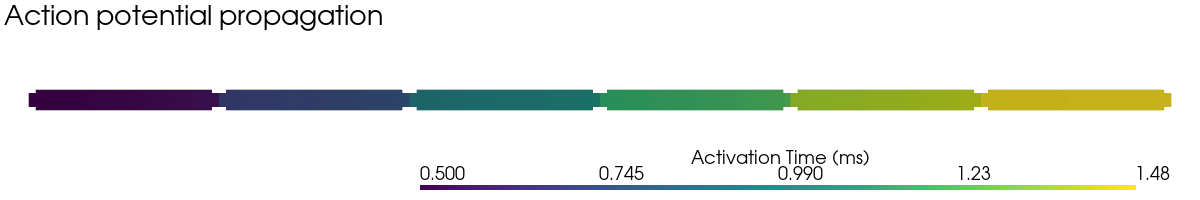

In [14]:
plotter = pyvista.Plotter(window_size=[1200, 200])
plotter.add_text("Action potential propagation", font_size=12)

for k in range(N_cells):
    topology, cell_types, geometry = plot.vtk_mesh(Vi[k])
    grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

    # Check if the cell has fired. If not, plot gray cell.
    if np.all(t_act[k].x.array > 0):
        grid.point_data["Activation Time (ms)"] = t_act[k].x.array
        plotter.add_mesh(grid, scalars="Activation Time (ms)")
    else:
        plotter.add_mesh(grid, color="gray", show_edges=False)

plotter.camera.tight(padding=0.05, view="xy", adjust_render_window=False)
plotter.show()

### Computing conduction velocity

To evaluate how fast the electrical signal travels across our cell strand, we calculate the macroscopic conduction velocity. This metric provides the average wave speed over a multi-cell distance.

We compute this by recording the exact activation time at the center of two distant cells (in our case, Cell 3 and Cell 4). By dividing the physical distance between these two points ($\Delta x$) by the time difference between their activations ($\Delta t$), we obtain the overall speed of the traveling wave.

```{exercise} Compute the conduction velocity
:label: l15-conduction-velocity
During the simulation, we tracked the activation times (when $u>0$) in two points, in `t1_val` and `t2_val`. The coordinates of these points were defined in `eval_pt_1` and `eval_pt_2`.
Use these variables to compute the conduction velocity. Convert the result to units cm/s.
```

In [15]:
# Add code here


Above, we computed the macroscopic CV by averaging the speed of the wave over a multi-cell distance. However, the spatial detail of the EMI model allows us to also compute the continuous microscopic CV inside each cell.
By fitting a piecewise second-order polynomial (a spline) to the spatial activation times $t(x)$ along the length of a cell, we can calculate the instantaneous intracellular velocity as its.

Run the final plotting cell below to visualize this microscopic velocity profile.

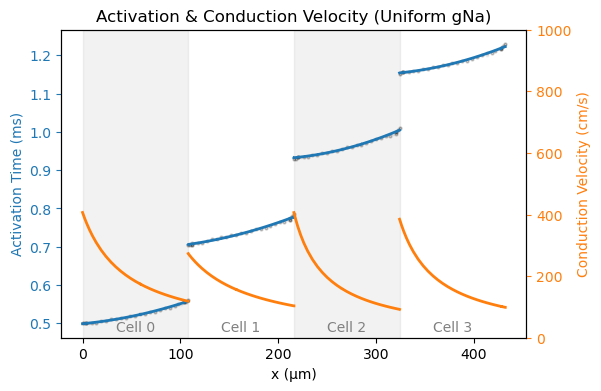

In [ ]:
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
import numpy as np

cells_to_plot = range(0, N_cells - 2)

fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.set_xlabel("x (µm)")
ax1.set_ylabel("Activation Time (ms)", color="tab:blue")
ax1.tick_params("y", colors="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Conduction Velocity (cm/s)", color="tab:orange")
ax2.tick_params("y", colors="tab:orange")

for k in cells_to_plot:
    # Get coordinates and activation times
    x, t = Vi[k].tabulate_dof_coordinates()[:, 0], t_act[k].x.array
    mask = t >= 0.0
    idx = np.argsort(x[mask])
    x_cm, t_val = x[mask][idx], t[mask][idx]

    x_um = x_cm * 10000.0  # convert to µm

    # Cell labels & shading
    ax1.text(
        x_um.mean(),
        0.02,
        f"Cell {k}",
        transform=ax1.get_xaxis_transform(),
        ha="center",
        color="gray",
    )
    if k % 2 == 0:
        ax1.axvspan(x_um[0], x_um[-1], color="gray", alpha=0.1, zorder=0)

    # Calculate CV
    spline = UnivariateSpline(x_cm, t_val, k=2, s=0.001)
    cv = 1000.0 / np.maximum(spline.derivative()(x_cm), 1e-8)

    ax1.plot(x_um, t_val, "ko", markersize=2, alpha=0.05)
    ax1.plot(x_um, spline(x_cm), color="tab:blue", linewidth=2)
    ax2.plot(x_um, cv, color="tab:orange", linewidth=2)

ax2.set_ylim(0, 1000)
plt.title("Activation & Conduction Velocity (Uniform gNa)")
plt.savefig("output/EMI_chain_CV_uniform.png")
plt.show()

## References
```{bibliography}
   :filter: cited
   :labelprefix:
   :keyprefix: emiconduction-
```